In [1]:
import pandas as pd
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/UpdatedResumeDataSet.csv")

In [3]:
df

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."
...,...,...
957,Testing,Computer Skills: â¢ Proficient in MS office (...
958,Testing,â Willingness to accept the challenges. â ...
959,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...


In [4]:
df.shape

(962, 2)

In [5]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [6]:
df['Resume'] = df['Resume'].fillna('')
df['Category'] = df['Category'].fillna('Unknown')

In [7]:
df.drop_duplicates(subset=['Resume'], inplace=True)

In [8]:
stop_words = ENGLISH_STOP_WORDS

def clean_text(text):
    text = re.sub(r'<.*?>', '', str(text))
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    tokens = [word for word in text.split() if word not in stop_words]
    return ' '.join(tokens)

In [9]:
df['Cleaned_Resume'] = df['Resume'].apply(clean_text)

In [10]:
df['Cleaned_Resume']

,Cleaned_Resume
0,skills programming languages python pandas num...
1,education details b e uit rgpv data scientist ...
2,areas deep learning control design programming...
3,skills r python sap hana tableau sap hana sql ...
4,education details mca ymcaust faridabad haryan...
...,...
894,computer skills proficient ms office word basi...
895,willingness accept challenges positive thinkin...
896,personal skills quick learner eagerness learn ...
897,computer skills software knowledge ms power po...


/tmp/ipython-input-3282068273.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')


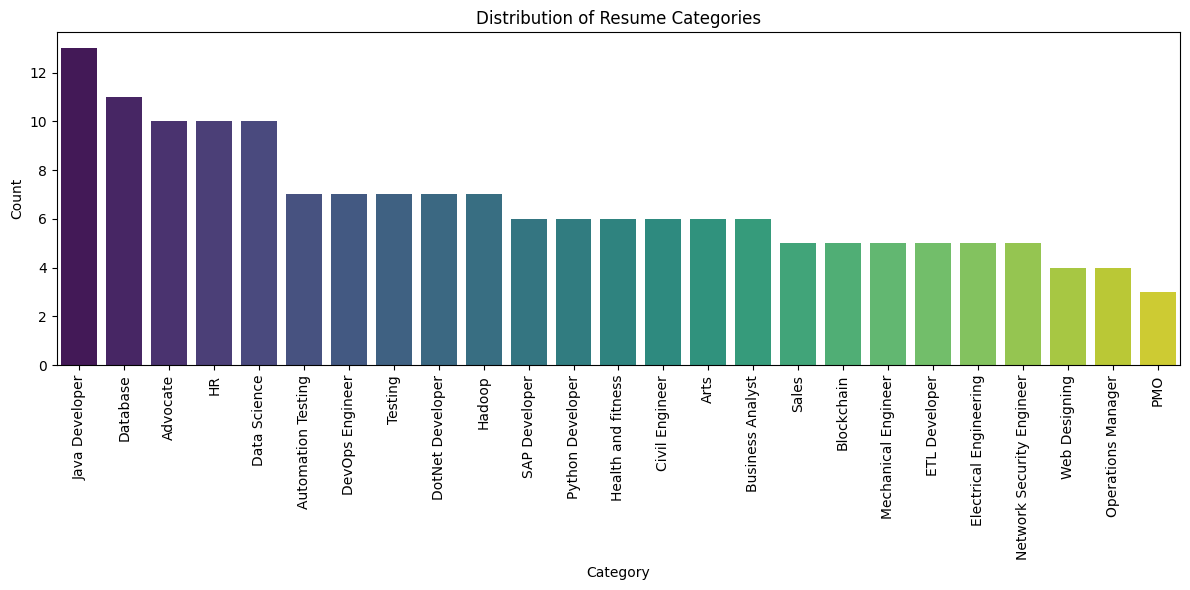

In [11]:
category_counts = df['Category'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title("Distribution of Resume Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [12]:
X = df['Cleaned_Resume']
y = df['Category']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [15]:
# Logistic Regression
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_tfidf, y_train)
log_pred = log_model.predict(X_test_tfidf)

In [16]:
# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

In [17]:
# SVM
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

In [18]:
print("🔹 Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
#print(classification_report(y_test, log_pred))

print("🔹 Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
#print(classification_report(y_test, nb_pred))

print("🔹 SVM Accuracy:", accuracy_score(y_test, svm_pred))
#print(classification_report(y_test, svm_pred))


🔹 Logistic Regression Accuracy: 0.4411764705882353
🔹 Naive Bayes Accuracy: 0.23529411764705882
🔹 SVM Accuracy: 0.9411764705882353


In [19]:
best_model = svm_model

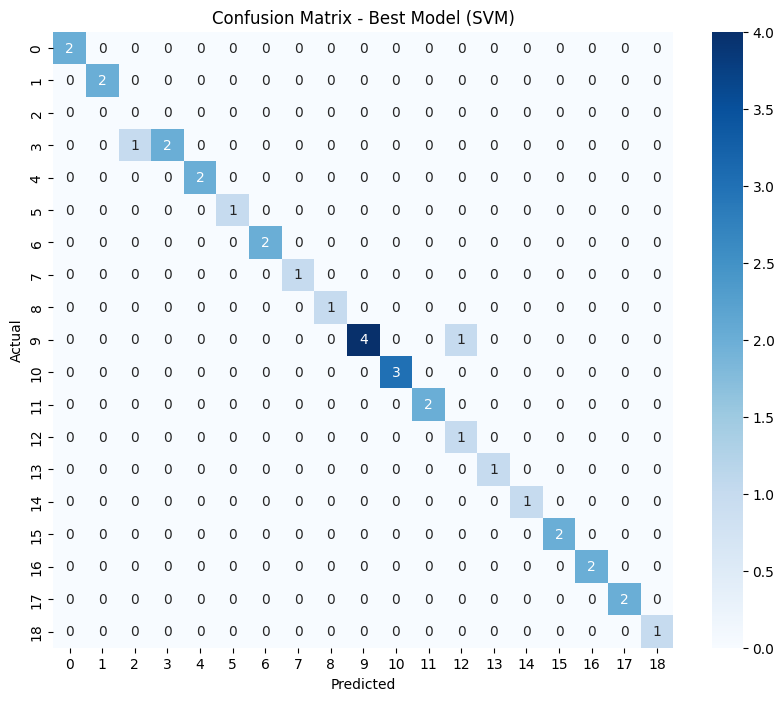

In [20]:
y_pred = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Best Model (SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
joblib.dump(best_model, "Dataset2.pkl")
joblib.dump(tfidf, "tfidf_Dataset2.pkl")

print("\n✅ Model and Vectorizer saved successfully!")


✅ Model and Vectorizer saved successfully!


In [22]:
def predict_job_role(text):
    """Predicts the job role from a given job description."""
    clean = clean_text(text)
    vector = tfidf.transform([clean])
    return best_model.predict(vector)[0]

In [23]:
# Example Prediction
print("Job Description:")
sample = input()
#print(sample)
print("Predicted Role:", predict_job_role(sample))

Job Description:
Data Analyst skilled in SQL, Python, and Power BI. The role involves cleaning, analyzing, and visualizing large datasets to generate business insights.
Predicted Role: Data Science
